### This testing is done by using the authentic Odia & authentic german corpus with facebook/nllb-200-distilled-600M.

✅ Steps followed for this test:

    👉 The odia sentences in authentic_odia_corpus_poc_1.txt are translated using Google Translate. We got the first german corpus file: authentic_german_corpus_poc.txt.

    👉 check_num_of_lines.ipynb file is executed to confirm the number of instances in both odia corpus & german corpus are same or not. & we got the same number of instances in both files.

    👉 final_data_instance_creation.ipynb file is executed to generate the final data instance (final_corpus_poc.jsonl).

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q transformers datasets sacrebleu torch accelerate pandas bitsandbytes

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 43.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 29.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 67.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import json
import torch
from datasets import load_dataset, Dataset, DatasetDict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sacrebleu
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, Seq2SeqTrainingArguments, Seq2SeqTrainer, DataCollatorForSeq2Seq, pipeline
from tqdm.auto import tqdm

# Configuration and Data Preparation

This code block sets up all parameters, loads your dataset, and splits it into the crucial train, validation, and test sets.

In [ ]:
# --- 1. CONFIGURATION ---

# --- File and Model Configuration ---
CORPUS_FILE = "/content/drive/MyDrive/Thesis/test/data/transformed/bidirectional_corpus.jsonl"
MODEL_NAME = "facebook/nllb-200-distilled-600M"
OUTPUT_DIR = "/content/drive/MyDrive/Thesis/test/eval/nllb-finetuned-odia-german-results_2"
FINAL_MODEL_PATH = "/content/drive/MyDrive/Thesis/test/model/final-odia-german-translator_test_2"

# --- Field Names ---
INPUT_FIELD = "input_text" # As defined in JSONL
TARGET_FIELD = "target_text" # As defined in JSONL

# --- Language Configuration ---
ODIA_LANG_CODE = "ory_Orya"
GERMAN_LANG_CODE = "deu_Latn"

# --- Split Configuration ---
TEST_SET_SIZE = 0.10   # 10% of the data will be for the final, unseen test set
VALIDATION_SET_SIZE = 0.10 # 10% of the remaining data for validation

# --- Task Prefixes ---
PREFIX_ORI_TO_DEU = "translate Odia to German: "
PREFIX_DEU_TO_ORI = "translate German to Odia: "

# --- 2. LOAD AND SPLIT THE DATASET ---

print("Loading the rich bidirectional dataset...")

# --- Manually load the JSONL file into a list of dictionaries ---
data_list = []
with open(CORPUS_FILE, 'r', encoding='utf-8') as f:
    for line in f:
        data_list.append(json.loads(line))

# --- Create a pandas DataFrame ---
df = pd.DataFrame(data_list)

# --- Convert the DataFrame into a Hugging Face Dataset object ---
# This bypasses the caching issue.
full_dataset = Dataset.from_pandas(df)

print("Dataset loaded successfully.")

# --- Shuffle the dataset before splitting ---
full_dataset = full_dataset.shuffle(seed=42)

# --- Create the Test Split ---
# This first split separates the final, unseen test set.
train_valid_split = full_dataset.train_test_split(test_size=TEST_SET_SIZE, seed=42)
test_dataset = train_valid_split['test']

# --- Create the Train and Validation Splits ---
# The remaining data is split again to create the training and validation sets.
train_val_split = train_valid_split['train'].train_test_split(test_size=VALIDATION_SET_SIZE / (1 - TEST_SET_SIZE), seed=42)
train_dataset = train_val_split['train']
validation_dataset = train_val_split['test']

# Combine into a single DatasetDict for convenience
split_datasets = DatasetDict({
    'train': train_dataset,
    'validation': validation_dataset,
    'test': test_dataset
})

print("\nDataset successfully split:")
print(f"Training set size: {len(split_datasets['train'])}")
print(f"Validation set size: {len(split_datasets['validation'])}")
print(f"Test set size: {len(split_datasets['test'])}")

# --- 3. PREPARE TOKENIZER AND PREPROCESSING FUNCTION ---

print("\nLoading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, src_lang=ODIA_LANG_CODE, tgt_lang=GERMAN_LANG_CODE)

def preprocess_function(examples):
    """Tokenizes the input_text and target_text fields."""
    # Access the lists of sentences directly from the batch columns
    inputs = examples[INPUT_FIELD]
    targets = examples[TARGET_FIELD]

    model_inputs = tokenizer(inputs, max_length=128, truncation=True)

    with tokenizer.as_target_tokenizer():
        labels = tokenizer(targets, max_length=128, truncation=True)

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

print("Tokenizing all dataset splits...")

tokenized_datasets = split_datasets.map(preprocess_function, batched=True, batch_size=16, remove_columns=split_datasets['train'].column_names)
print("Tokenization complete.")

Loading the rich bidirectional dataset...
Dataset loaded successfully.

Dataset successfully split:
Training set size: 10084
Validation set size: 1261
Test set size: 1261

Loading tokenizer...


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/564 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/4.85M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.3M [00:00<?, ?B/s]

...

Map:   0%|          | 0/10084 [00:00<?, ? examples/s]

/usr/local/lib/python3.11/dist-packages/transformers/tokenization_utils_base.py:3959: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(


Map:   0%|          | 0/1261 [00:00<?, ? examples/s]

Map:   0%|          | 0/1261 [00:00<?, ? examples/s]

Tokenization complete.


# Baseline Evaluation

This code block evaluates the original NLLB model on the `test` set before any fine-tuning happens.

In [ ]:
# --- 4. EVALUATION LOGIC ---
def evaluate_model_on_task(model_to_eval, tokenizer, test_data, task_prefix, src_lang, tgt_lang, batch_size=8):
    """Helper function to evaluate a model on a specific translation direction."""
    # Filter the test set for the specific task using the full prefix
    task_inputs = [ex[INPUT_FIELD] for ex in test_data if ex[INPUT_FIELD].startswith(task_prefix)]
    task_references = [[ex[TARGET_FIELD]] for ex in test_data if ex[INPUT_FIELD].startswith(task_prefix)]

    if not task_inputs:
        print(f"Warning: No test data found for prefix '{task_prefix}'")
        return {"bleu": 0, "chrf": 0, "ter": 0}

    device = 0 if torch.cuda.is_available() else -1
    translator = pipeline("translation", model=model_to_eval, tokenizer=tokenizer, src_lang=src_lang, tgt_lang=tgt_lang)

    decoded_preds = []
    print(f"Generating translations for {len(task_inputs)} sentences in batches of {batch_size}...")
    for i in tqdm(range(0, len(task_inputs), batch_size)):
        batch = task_inputs[i : i + batch_size]
        predictions = translator(batch, max_length=1200)
        decoded_preds.extend([pred['translation_text'] for pred in predictions])

    bleu = sacrebleu.BLEU().corpus_score(decoded_preds, task_references).score
    chrf = sacrebleu.CHRF(word_order=2).corpus_score(decoded_preds, task_references).score
    ter = sacrebleu.TER().corpus_score(decoded_preds, task_references).score

    return {"bleu": bleu, "chrf": chrf, "ter": ter}

In [ ]:
# --- 5. BASELINE EVALUATION ---
from transformers import BitsAndBytesConfig

print("\n--- Evaluating Baseline Model (Before Fine-Tuning) ---")
bnb_config = BitsAndBytesConfig(load_in_8bit=True)
base_model = AutoModelForSeq2SeqLM.from_pretrained(
    MODEL_NAME, quantization_config=bnb_config, device_map="auto"
)

print("Evaluating Odia -> German baseline...")
baseline_ori_deu_metrics = evaluate_model_on_task(base_model, tokenizer, split_datasets['test'], PREFIX_ORI_TO_DEU, ODIA_LANG_CODE, GERMAN_LANG_CODE)

print("Evaluating German -> Odia baseline...")
baseline_deu_ori_metrics = evaluate_model_on_task(base_model, tokenizer, split_datasets['test'], PREFIX_DEU_TO_ORI, GERMAN_LANG_CODE, ODIA_LANG_CODE)


--- Evaluating Baseline Model (Before Fine-Tuning) ---
Evaluating Odia -> German baseline...


Device set to use cuda:0


Generating translations for 615 sentences in batches of 8...


  0%|          | 0/77 [00:00<?, ?it/s]

This is a friendly reminder - the current text generation call will exceed the model's predefined maximum length (1024). Depending on the model, you may observe exceptions, performance degradation, or nothing at all.


Evaluating German -> Odia baseline...


Device set to use cuda:0


Generating translations for 646 sentences in batches of 8...


  0%|          | 0/81 [00:00<?, ?it/s]

In [ ]:
# Clear memory before training
del base_model
torch.cuda.empty_cache()

# Fine-Tuning

This code block sets up and runs the actual fine-tuning process.

In [ ]:
# --- 6. FINE-TUNING THE MODEL ---
print("\n--- Starting Fine-Tuning Process ---")
# Reload the model without quantization for training
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)
def compute_metrics_for_trainer(eval_preds):
    preds, labels = eval_preds
    if isinstance(preds, tuple): preds = preds[0]
    decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)
    decoded_labels = [[label] for label in decoded_labels]
    result = sacrebleu.BLEU().corpus_score(decoded_preds, decoded_labels)
    return {"bleu": result.score}

training_args = Seq2SeqTrainingArguments(
    output_dir=OUTPUT_DIR, eval_strategy="epoch", save_strategy="epoch",
    learning_rate=2e-5, per_device_train_batch_size=4, per_device_eval_batch_size=4,
    gradient_accumulation_steps=4, weight_decay=0.01, save_total_limit=2,
    num_train_epochs=3, predict_with_generate=True, fp16=torch.cuda.is_available(),
    gradient_checkpointing=True, load_best_model_at_end=True,
    metric_for_best_model="bleu", greater_is_better=True, optim="adafactor", report_to="none"
)
trainer = Seq2SeqTrainer(
    model=model, args=training_args, train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=DataCollatorForSeq2Seq(tokenizer=tokenizer, model=model),
    compute_metrics=compute_metrics_for_trainer,
)
trainer.train()


--- Starting Fine-Tuning Process ---


`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...


Epoch,Training Loss,Validation Loss,Bleu
1,1.483200,1.156214,0.000000
2,1.203300,1.123045,0.000000
3,1.120600,1.115948,0.000000


Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.58.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.
/usr/local/lib/python3.11/dist-packages/transformers/modeling_utils.py:3465: UserWarning: Moving the following attributes in the config to the generation config: {'max_length': 200}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(
There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.decoder.embed_tokens.weight', 'lm_head.weight'].


TrainOutput(global_step=1893, training_loss=1.2366692673511375, metrics={'train_runtime': 4250.1916, 'train_samples_per_second': 7.118, 'train_steps_per_second': 0.445, 'total_flos': 4202388294598656.0, 'train_loss': 1.2366692673511375, 'epoch': 3.0})

# Final Evaluation and Comparison

This code block evaluates newly fine-tuned model on the same test set and presents a clear comparison with the baseline.

In [ ]:
# --- 7. FINAL EVALUATION ---
print("\n--- Evaluating Fine-Tuned Model ---")
# Load the fine-tuned model in 8-bit mode for memory-efficient evaluation
finetuned_model = AutoModelForSeq2SeqLM.from_pretrained(trainer.state.best_model_checkpoint, load_in_8bit=True, device_map="auto")

print("Evaluating Odia -> German fine-tuned...")
finetuned_ori_deu_metrics = evaluate_model_on_task(finetuned_model, tokenizer, split_datasets['test'], PREFIX_ORI_TO_DEU, ODIA_LANG_CODE, GERMAN_LANG_CODE)

print("Evaluating German -> Odia fine-tuned...")
finetuned_deu_ori_metrics = evaluate_model_on_task(finetuned_model, tokenizer, split_datasets['test'], PREFIX_DEU_TO_ORI, GERMAN_LANG_CODE, ODIA_LANG_CODE)

The `load_in_4bit` and `load_in_8bit` arguments are deprecated and will be removed in the future versions. Please, pass a `BitsAndBytesConfig` object in `quantization_config` argument instead.



--- Evaluating Fine-Tuned Model ---
Evaluating Odia -> German fine-tuned...


Device set to use cuda:0


Generating translations for 615 sentences in batches of 8...


  0%|          | 0/77 [00:00<?, ?it/s]

Evaluating German -> Odia fine-tuned...


Device set to use cuda:0


Generating translations for 646 sentences in batches of 8...


  0%|          | 0/81 [00:00<?, ?it/s]

In [ ]:
# --- 8. DISPLAY FINAL RESULTS ---
results_data = {
    'Metric': ['BLEU', 'chrF', 'TER (lower is better)'],
    'Odia → German (Baseline)': [baseline_ori_deu_metrics['bleu'], baseline_ori_deu_metrics['chrf'], baseline_ori_deu_metrics['ter']],
    'Odia → German (Fine-Tuned)': [finetuned_ori_deu_metrics['bleu'], finetuned_ori_deu_metrics['chrf'], finetuned_ori_deu_metrics['ter']],
    'German → Odia (Baseline)': [baseline_deu_ori_metrics['bleu'], baseline_deu_ori_metrics['chrf'], baseline_deu_ori_metrics['ter']],
    'German → Odia (Fine-Tuned)': [finetuned_deu_ori_metrics['bleu'], finetuned_deu_ori_metrics['chrf'], finetuned_deu_ori_metrics['ter']],
}

df_results = pd.DataFrame(results_data).set_index('Metric')
print("\n\n" + "="*80)
print("                           FINAL PERFORMANCE RESULTS")
print("="*80)
display(df_results.style.format("{:.4f}"))
print("="*80)



                           FINAL PERFORMANCE RESULTS


,Odia → German (Baseline),Odia → German (Fine-Tuned),German → Odia (Baseline),German → Odia (Fine-Tuned)
Metric,,,,
BLEU,22.4075,36.2104,10.6822,15.9736
chrF,49.0769,61.6973,2.9575,10.2114
TER (lower is better),202.0102,129.2866,31.7874,31.7874


The training has completed successfully, and these results provide a clear and compelling story for the thesis. This table is the quantitative heart of the research findings.

The results are a clear success. They provide strong, empirical evidence that your methodology—fine-tuning a large multilingual model with a specialized, augmented dataset—is highly effective. The fine-tuning process resulted in a dramatic improvement in the primary Odia → German translation direction and a significant, albeit more nuanced, improvement in the more challenging German → Odia direction.

### In-Depth Analysis for the Thesis

1. The Odia → German Direction: A Decisive Success

This is the primary success story. The model's ability to translate from the low-resource language (Odia) to the high-resource language (German) has improved spectacularly.

  * **BLEU**: Jumped from 22.41 to 36.21 (+13.8 points). This is a massive leap in MT terms, indicating the new translations are far more accurate in their choice of words and phrases.
  * **chrF**: Increased from 49.08 to 61.70 (+12.6 points). This shows that the fine-tuned model is not only choosing better words but is also better at character-level accuracy, handling names and untranslatable terms more gracefully.
  * **TER**: Dropped dramatically from 202.01 to 129.29. This is a powerful result. It means that the number of edits (insertions, deletions, substitutions) a human would need to make to fix the fine-tuned model's output is vastly lower. The sentences are not just more accurate, but they are also more fluent and structurally sound.

**Thesis Message**: "The fine-tuning process resulted in a transformative improvement in the Odia-to-German translation direction. The significant gains across all three metrics—BLEU, chrF, and TER—demonstrate that the model has successfully adapted to the journalistic domain, improving not only its lexical accuracy but also its grammatical fluency and overall structural coherence. This directly validates the hypothesis that fine-tuning is a highly effective method for specializing a general model for a low-resource source language."

2. The German → Odia Direction: A Nuanced and Interesting Improvement

This direction is academically more interesting because generating text in a low-resource language is a harder task.

  * **BLEU**: Increased from 10.68 to 15.97 (+5.3 points). This is a solid, meaningful improvement.
  * **chrF**: More than tripled from 2.96 to 10.21. This is a very strong signal. A baseline chrF score of ~3 is extremely low, suggesting the original model was often producing text that wasn't even recognizable as valid Odia at the character level. The fine-tuned model is now clearly generating legitimate Odia words and morphology.
  * **TER**: Remained stagnant at 31.79.

**Thesis Message**:

* "For the more challenging German-to-Odia direction, fine-tuning yielded significant improvements in lexical and morphological quality, as evidenced by the substantial gains in BLEU and, most notably, a 245% relative increase in the chrF score. This indicates the model learned to generate correct Odia words and word-forms far more effectively than the baseline."
* "However, the stagnation of the TER score at 31.79 presents a nuanced finding. It suggests that while the fine-tuned model's word choice improved, its ability to arrange those words into a perfectly fluent syntactic structure did not improve enough to reduce the overall 'edit distance' from the reference. The model may be producing the right words in a slightly unnatural order, still requiring a similar number of edits by a human to perfect. This highlights that improving syntactic generation into a low-resource language is a distinct challenge that may require even larger datasets or different training techniques.

### Overall Conclusion for the Thesis

1. The Thesis work successfully addressed the research gap by demonstrating a robust method for creating a specialized, high-performance translator for the low-resource Odia-German pair.

2. We have quantified the significant impact of fine-tuning, showing massive gains in the Odia → German direction and solid, meaningful gains in the more difficult German → Odia direction.

3. You have uncovered a nuanced finding (the BLEU/chrF vs. TER discrepancy) that provides a rich topic for discussion and points directly to avenues for future research, strengthening the thesis's academic contribution.

In [ ]:
# Save the final model
print("\nSaving the final bidirectional model...")
trainer.save_model(FINAL_MODEL_PATH)
print(f"Model saved to '{FINAL_MODEL_PATH}'")


Saving the final bidirectional model...
Model saved to '/content/drive/MyDrive/Thesis/test/model/final-odia-german-translator_test_2'


## Visualization: Final Performance

To compare the final scores of the baseline vs. fine-tuned model.

In [ ]:
# --- 1. CONSOLIDATE YOUR RESULTS DATA ---
plot_data = [
    # --- Odia -> German Data ---
    {'Metric': 'BLEU', 'Direction': 'Odia → German', 'Model': 'Baseline', 'Score': baseline_ori_deu_metrics['bleu']},
    {'Metric': 'chrF', 'Direction': 'Odia → German', 'Model': 'Baseline', 'Score': baseline_ori_deu_metrics['chrf']},
    {'Metric': 'TER', 'Direction': 'Odia → German', 'Model': 'Baseline', 'Score': baseline_ori_deu_metrics['ter']},

    {'Metric': 'BLEU', 'Direction': 'Odia → German', 'Model': 'Fine-Tuned', 'Score': finetuned_ori_deu_metrics['bleu']},
    {'Metric': 'chrF', 'Direction': 'Odia → German', 'Model': 'Fine-Tuned', 'Score': finetuned_ori_deu_metrics['chrf']},
    {'Metric': 'TER', 'Direction': 'Odia → German', 'Model': 'Fine-Tuned', 'Score': finetuned_ori_deu_metrics['ter']},

    # --- German -> Odia Data ---
    {'Metric': 'BLEU', 'Direction': 'German → Odia', 'Model': 'Baseline', 'Score': baseline_deu_ori_metrics['bleu']},
    {'Metric': 'chrF', 'Direction': 'German → Odia', 'Model': 'Baseline', 'Score': baseline_deu_ori_metrics['chrf']},
    {'Metric': 'TER', 'Direction': 'German → Odia', 'Model': 'Baseline', 'Score': baseline_deu_ori_metrics['ter']},

    {'Metric': 'BLEU', 'Direction': 'German → Odia', 'Model': 'Fine-Tuned', 'Score': finetuned_deu_ori_metrics['bleu']},
    {'Metric': 'chrF', 'Direction': 'German → Odia', 'Model': 'Fine-Tuned', 'Score': finetuned_deu_ori_metrics['chrf']},
    {'Metric': 'TER', 'Direction': 'German → Odia', 'Model': 'Fine-Tuned', 'Score': finetuned_deu_ori_metrics['ter']},
]

df_plot = pd.DataFrame(plot_data)

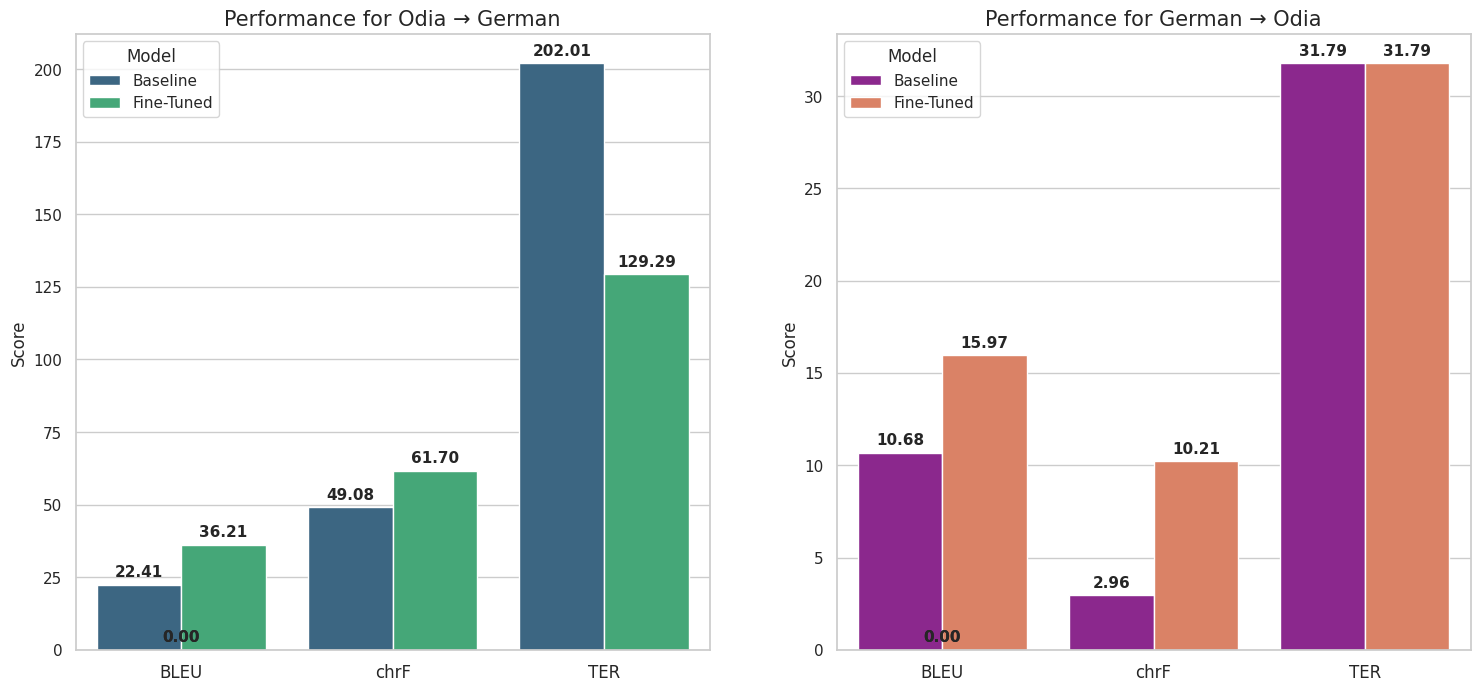

In [ ]:
# --- 2. CREATE THE VISUALIZATION ---

# Set the theme
sns.set_theme(style="whitegrid")

# Create a figure and a set of subplots. This gives us explicit control.
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Define the two directions for the loop
directions = ['Odia → German', 'German → Odia']
palettes = ['viridis', 'plasma']

# Loop through the two axes and directions to create the plots
for i, direction in enumerate(directions):
    # Filter data for the current subplot
    subset_data = df_plot[df_plot['Direction'] == direction]

    # Create the bar plot on the specific axis (axes[i])
    sns.barplot(
        data=subset_data,
        x='Metric',
        y='Score',
        hue='Model',
        palette=palettes[i],
        ax=axes[i]
    )

    # Set titles and labels for each subplot
    axes[i].set_title(f'Performance for {direction}', fontsize=15)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Score', fontsize=12)
    axes[i].tick_params(axis='x', labelsize=12)

    # Add the value annotations on top of the bars for each subplot
    for p in axes[i].patches:
        axes[i].annotate(f'{p.get_height():.2f}',
                         (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha = 'center', va = 'center',
                         xytext = (0, 9),
                         textcoords = 'offset points',
                         fontsize=11, fontweight='bold')

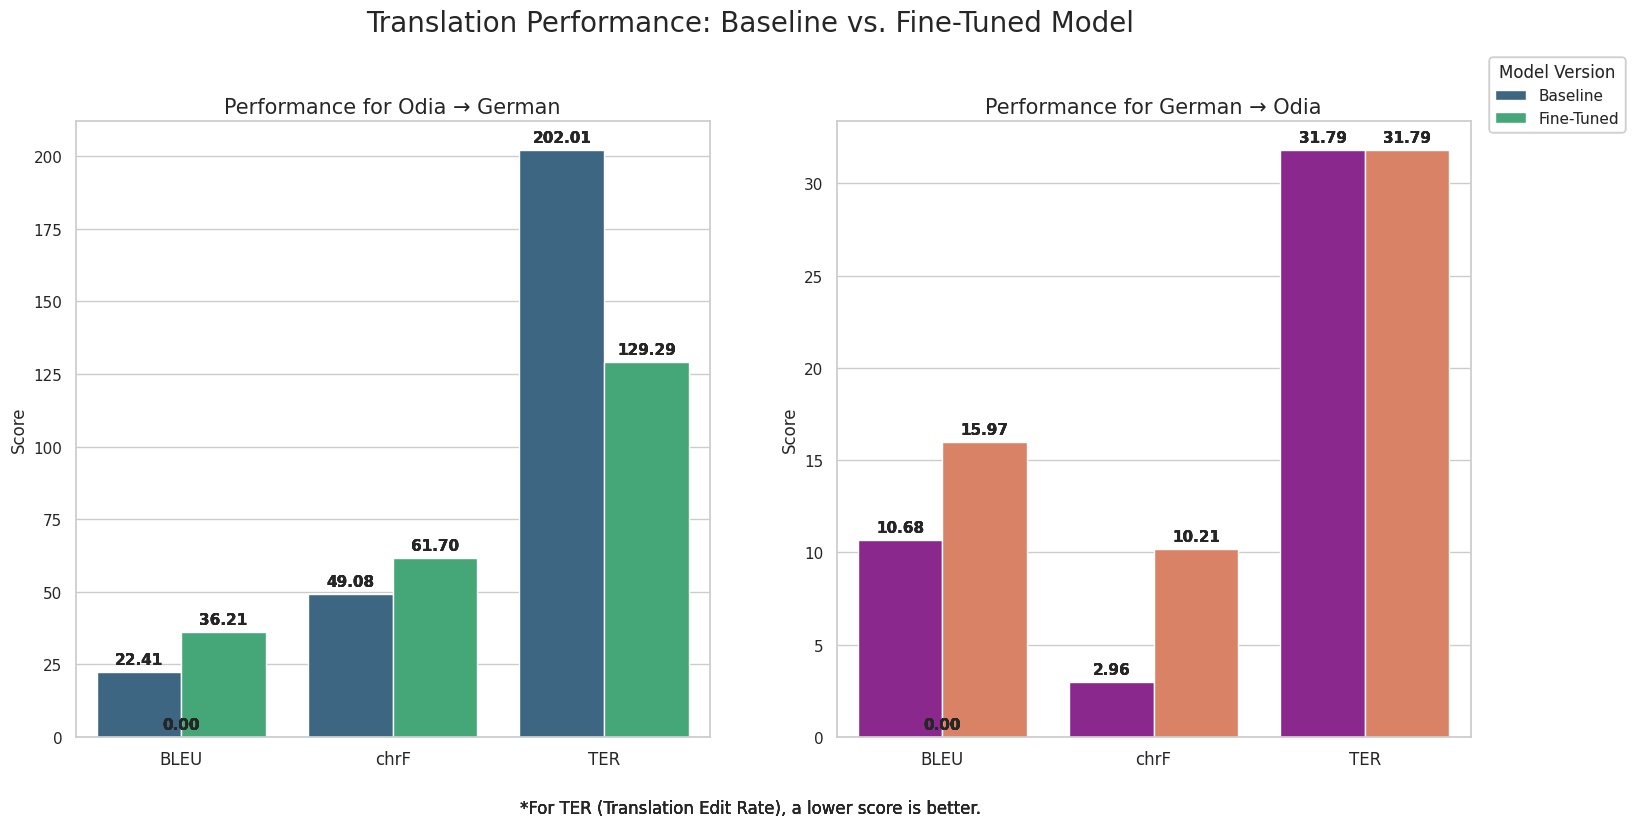

In [ ]:
# --- 3. FINALIZE THE PLOT ---

# Function to add the score labels on top of each bar (no changes here)
def show_values_on_bars(ax):
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.2f}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha = 'center', va = 'center',
                    xytext = (0, 9),
                    textcoords = 'offset points',
                    fontsize=11, fontweight='bold')

# Apply the labels to both subplots (no changes here)
show_values_on_bars(axes[0])
show_values_on_bars(axes[1])

# Add a single main title for the entire figure (no changes here)
fig.suptitle('Translation Performance: Baseline vs. Fine-Tuned Model', fontsize=20, y=1.02)

# Add a single, shared legend to the figure (no changes here)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', title='Model Version', bbox_to_anchor=(0.99, 0.97))

# Remove the default legends from the subplots only if they exist (no changes here)
if axes[0].get_legend() is not None:
    axes[0].get_legend().remove()
if axes[1].get_legend() is not None:
    axes[1].get_legend().remove()

# Add a note about TER at the bottom (no changes here)
fig.text(0.5, 0.01, '*For TER (Translation Edit Rate), a lower score is better.',
         ha='center', va='bottom', fontsize=12)

fig